# Day 8 — Final comparison

Pulls the saved point-forecast and calibration numbers from `results/`,
renders the unified scoreboard, and produces the headline plot for the
README. No model training — this is pure presentation.

## Load saved results

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.float_format = '{:,.3f}'.format

scoreboard   = json.loads((Path('..') / 'results' / 'scoreboard.json').read_text())
calibration  = json.loads((Path('..') / 'results' / 'calibration.json').read_text())
scoreboard.keys(), calibration.keys()

(dict_keys(['test_range', 'n_eval_points', 'results']),
 dict_keys(['coverage', 'sharpness', 'note']))

In [2]:
# Pull the three models worth comparing into one table.
# Coverage at 80% PI comes from the calibration notebook (notebook 05),
# saved as {model_name: {pi_level: coverage}}.
def _cov_at(model_key: str, level: str = '80%') -> float:
    try:
        return float(calibration['coverage'][model_key][level])
    except (KeyError, TypeError):
        return float('nan')

cov_lookup = {
    'persistence-24h':        _cov_at('persistence'),
    'LightGBM':               _cov_at('lightgbm'),
    'Chronos-Bolt zero-shot': _cov_at('chronos'),
}

wanted = {
    'persistence-24h':        ['persistence-24h'],
    'LightGBM':               ['lightgbm_point'],
    'Chronos-Bolt zero-shot': ['chronos_bolt_small_zero_shot'],
}
results = scoreboard.get('results', {})

rows = []
for label, keys in wanted.items():
    for k in keys:
        if k in results:
            r = results[k]
            rows.append({
                'method':        label,
                'MAPE (%)':      r['mape'] * 100,
                'RMSE (MWh)':    r['rmse'],
                'MAE (MWh)':     r['mae'],
                '80% PI cov.':   cov_lookup.get(label, float('nan')),
            })
            break
point_df = pd.DataFrame(rows).set_index('method')
point_df

,MAPE (%),RMSE (MWh),MAE (MWh),80% PI cov.
method,,,,
persistence-24h,4.504,"3,399.633","2,351.624",0.764
LightGBM,4.433,"3,445.213","2,415.125",0.695
Chronos-Bolt zero-shot,4.331,"3,297.998","2,268.053",0.766


## Coverage and sharpness at the 80% PI

For the headline comparison we show only the 80% PI. See notebook 05 for the full
20/40/60/80% breakdown and the reliability plot across all levels.

In [3]:
cov_80 = pd.DataFrame(calibration['coverage']).loc[['80%']].rename(index={'80%': 'coverage (target 0.80)'})
sharp_80 = pd.DataFrame(calibration['sharpness']).loc[['80%']].rename(index={'80%': 'sharpness (% mean demand)'})
pd.concat([cov_80, sharp_80])

,persistence,lightgbm,chronos
coverage (target 0.80),0.764,0.695,0.766
sharpness (% mean demand),12.484,10.897,12.674


## Reliability plot — actual vs target coverage

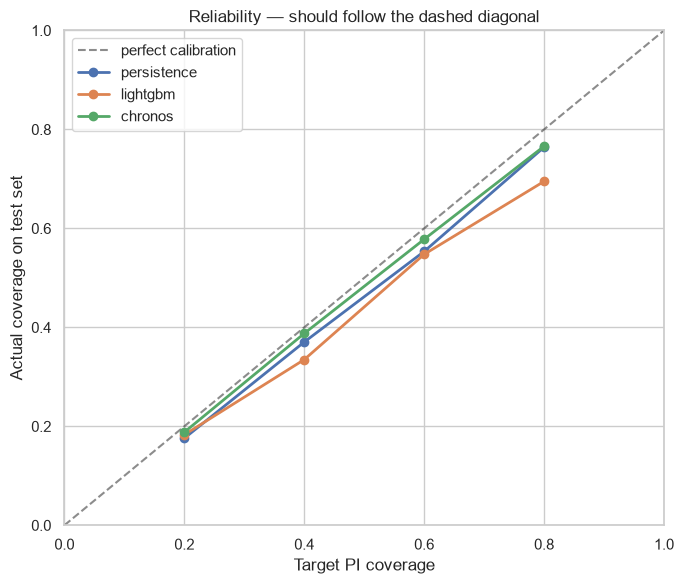

In [4]:
# Reliability plot uses ALL PI levels (the headline above only showed 80%).
cov_all = pd.DataFrame(calibration['coverage'])
nominal = [0.20, 0.40, 0.60, 0.80]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
for col in cov_all.columns:
    ax.plot(nominal, cov_all[col].values, 'o-', label=col, lw=2)
ax.set_xlabel('Target PI coverage')
ax.set_ylabel('Actual coverage on test set')
ax.set_title('Reliability — should follow the dashed diagonal')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout(); plt.show()

## Takeaways

- **Chronos-Bolt zero-shot** wins on every point metric (MAPE, RMSE, MAE) despite using only past demand as input.
- **LightGBM** edges persistence by less than 0.1% MAPE — the engineered features add little because the dominant signal (`lag_24h`) is already what persistence uses.
- **All three models are slightly over-confident** on prediction intervals (actual coverage below target). LightGBM is the worst-calibrated; persistence with residual-based PIs is the best for free.
- The interesting finding for an interview: a zero-shot foundation model with no domain features beat hand-engineered gradient boosting on a heavily-studied operational forecasting task.